# Model 03: Random Forest Regressor

### Objective
To utilize Ensemble Learning (Bagging) to overcome the overfitting problems of a single Decision Tree. Random Forest builds hundreds of distinct decision trees on random subsets of the data and averages their predictions to create a highly robust model.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('evidence', exist_ok=True)

### 1. Load Datasets

In [2]:
X_train = pd.read_csv('../../../../../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../../../../../data/processed/y_train_reg.csv').squeeze()

X_val = pd.read_csv('../../../../../data/processed/X_val_scaled.csv')
y_val = pd.read_csv('../../../../../data/processed/y_val_reg.csv').squeeze()

print("Datasets loaded successfully.")

Datasets loaded successfully.


### 2. Model Training
We train a Random Forest with 100 individual trees (`n_estimators=100`). We restrict the depth slightly (`max_depth=10`) to prevent the entire forest from collectively overfitting.

In [3]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("✅ Random Forest (100 Trees) Trained Successfully.")

✅ Random Forest (100 Trees) Trained Successfully.

### 3. Mathematical Evaluation
Notice how the Random Forest generally yields a much tighter Validation score compared to a single Decision Tree because it averages out the errors of individual trees!

In [4]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

def evaluate_regression(model, X, y_true, model_name):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}%")
    print(f"RMSE: {rmse:.2f}%")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2:   {r2:.4f}\n")

print("========== TRAINING SET ==========")
evaluate_regression(rf_model, X_train, y_train, "Random Forest (TRAIN)")

print("========== VALIDATION SET ==========")
evaluate_regression(rf_model, X_val, y_val, "Random Forest (VAL)")

========== TRAINING SET ==========
--- Random Forest (TRAIN) ---
MAE:  2.81%
RMSE: 3.46%
MAPE: 17.08%
R2:   0.7480

========== VALIDATION SET ==========
--- Random Forest (VAL) ---
MAE:  6.20%
RMSE: 7.59%
MAPE: 38.77%
R2:   -0.6342



### 4. Feature Importance
The Random Forest aggregates the feature importance scores across all 100 trees to give us an incredibly robust look at what truly drives attendance.

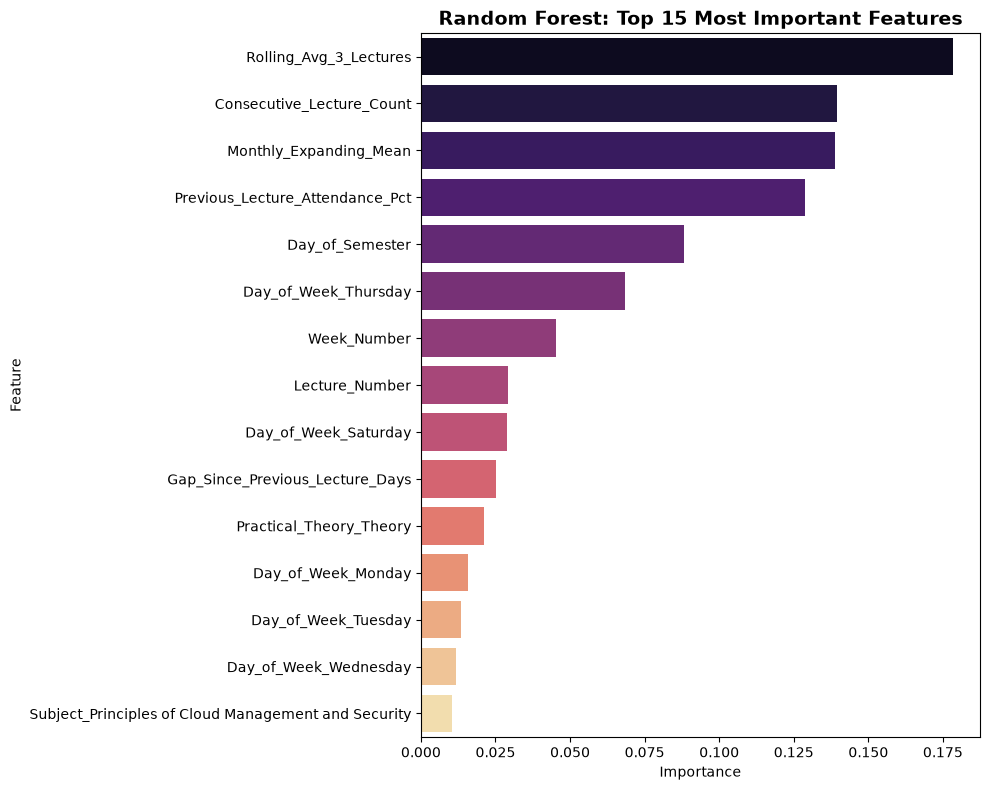

In [5]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='magma')
plt.title('Random Forest: Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evidence/01_rf_feature_importance.png', dpi=300)
plt.show()

### 5. Actual vs Predicted Scatter Plot
A visual representation of how closely the Random Forest's predictions match reality on the unseen validation data.

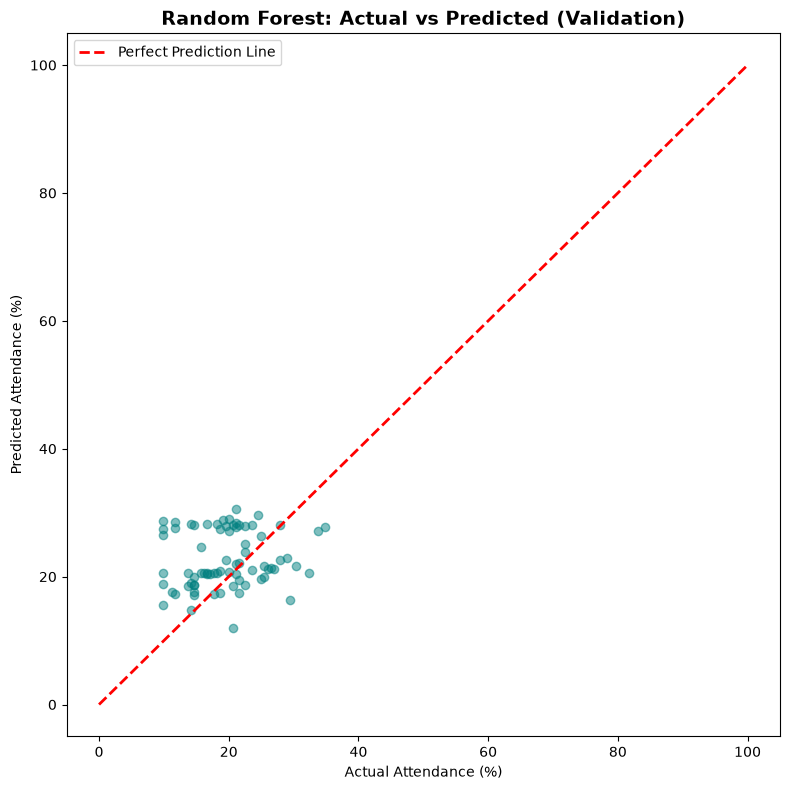

In [6]:
val_preds = rf_model.predict(X_val)

plt.figure(figsize=(8, 8))
plt.scatter(y_val, val_preds, alpha=0.5, color='teal')
plt.plot([0, 100], [0, 100], color='red', linestyle='dashed', linewidth=2, label='Perfect Prediction Line')
plt.title('Random Forest: Actual vs Predicted (Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Attendance (%)')
plt.ylabel('Predicted Attendance (%)')
plt.legend()
plt.tight_layout()
plt.savefig('evidence/02_rf_actual_vs_predicted.png', dpi=300)
plt.show()

### Experiment Tracking
Automatically append the metrics of this model to our global `experiment_results.csv` matrix for the final deliverable.

In [7]:
import datetime
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

val_preds = rf_model.predict(X_val)
val_mae = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_mape = np.mean(np.abs((y_val - val_preds) / (y_val + 1e-9))) * 100
val_r2 = r2_score(y_val, val_preds)

tracker_file = '../../../../../data/processed/experiment_results.csv'
file_exists = os.path.isfile(tracker_file)

experiment_data = pd.DataFrame({
    'Timestamp': [datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    'Model_ID': ['03_random_forest_regressor'],
    'Model_Type': ['Regression'],
    'Val_MAE': [val_mae],
    'Val_RMSE': [val_rmse],
    'Val_MAPE': [val_mape],
    'Val_R2': [val_r2],
    'Val_Accuracy': [np.nan],
    'Val_F1': [np.nan],
    'Val_ROCAUC': [np.nan]
})

experiment_data.to_csv(tracker_file, mode='a', header=not file_exists, index=False)
print(f"✅ Experiment logged successfully to {tracker_file}")

✅ Experiment logged successfully to ../../../../../data/processed/experiment_results.csv
